In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
import seaborn as sns

In [2]:
df= pd.read_csv('sales_data.csv')
df

,Product_ID,Sale_Date,Sales_Rep,Region,Sales_Amount,Quantity_Sold,Product_Category,Unit_Cost,Unit_Price,Customer_Type,Discount,Payment_Method,Sales_Channel,Region_and_Sales_Rep
0,1052,03/02/2023,Bob,North,5053.97,18,Furniture,152.75,267.22,Returning,0.09,Cash,Online,North-Bob
1,1093,21/04/2023,Bob,West,4384.02,17,Furniture,3816.39,4209.44,Returning,0.11,Cash,Retail,West-Bob
2,1015,21/09/2023,David,South,4631.23,30,Food,261.56,371.40,Returning,0.20,Bank Transfer,Retail,South-David
3,1072,24/08/2023,Bob,South,2167.94,39,Clothing,4330.03,4467.75,New,0.02,Credit Card,Retail,South-Bob
4,1061,24/03/2023,Charlie,East,3750.20,13,Electronics,637.37,692.71,New,0.08,Credit Card,Online,East-Charlie
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,1010,15/04/2023,Charlie,North,4733.88,4,Food,4943.03,5442.15,Returning,0.29,Cash,Online,North-Charlie
996,1067,07/09/2023,Bob,North,4716.36,37,Clothing,1754.32,1856.40,New,0.21,Bank Transfer,Retail,North-Bob
997,1018,27/04/2023,David,South,7629.70,17,Clothing,355.72,438.27,Returning,0.06,Bank Transfer,Online,South-David
998,1100,20/12/2023,David,West,1629.47,39,Electronics,3685.03,3743.39,New,0.01,Bank Transfer,Online,West-David


In [3]:
df.describe()

,Product_ID,Sales_Amount,Quantity_Sold,Unit_Cost,Unit_Price,Discount
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000
mean,1050.128000,5019.265230,25.355000,2475.304550,2728.440120,0.15239
std,29.573505,2846.790126,14.159006,1417.872546,1419.399839,0.08720
min,1001.000000,100.120000,1.000000,60.280000,167.120000,0.00000
25%,1024.000000,2550.297500,13.000000,1238.380000,1509.085000,0.08000
50%,1051.000000,5019.300000,25.000000,2467.235000,2696.400000,0.15000
75%,1075.000000,7507.445000,38.000000,3702.865000,3957.970000,0.23000
max,1100.000000,9989.040000,49.000000,4995.300000,5442.150000,0.30000


SEE AlL VARIABLES IN OUR DATASET

In [4]:
df.columns

Index(['Product_ID', 'Sale_Date', 'Sales_Rep', 'Region', 'Sales_Amount',
       'Quantity_Sold', 'Product_Category', 'Unit_Cost', 'Unit_Price',
       'Customer_Type', 'Discount', 'Payment_Method', 'Sales_Channel',
       'Region_and_Sales_Rep'],
      dtype='object')

In [5]:
#DRop missing values
df = df.dropna(axis=0)

In [6]:
df.head()

,Product_ID,Sale_Date,Sales_Rep,Region,Sales_Amount,Quantity_Sold,Product_Category,Unit_Cost,Unit_Price,Customer_Type,Discount,Payment_Method,Sales_Channel,Region_and_Sales_Rep
0,1052,03/02/2023,Bob,North,5053.97,18,Furniture,152.75,267.22,Returning,0.09,Cash,Online,North-Bob
1,1093,21/04/2023,Bob,West,4384.02,17,Furniture,3816.39,4209.44,Returning,0.11,Cash,Retail,West-Bob
2,1015,21/09/2023,David,South,4631.23,30,Food,261.56,371.40,Returning,0.20,Bank Transfer,Retail,South-David
3,1072,24/08/2023,Bob,South,2167.94,39,Clothing,4330.03,4467.75,New,0.02,Credit Card,Retail,South-Bob
4,1061,24/03/2023,Charlie,East,3750.20,13,Electronics,637.37,692.71,New,0.08,Credit Card,Online,East-Charlie


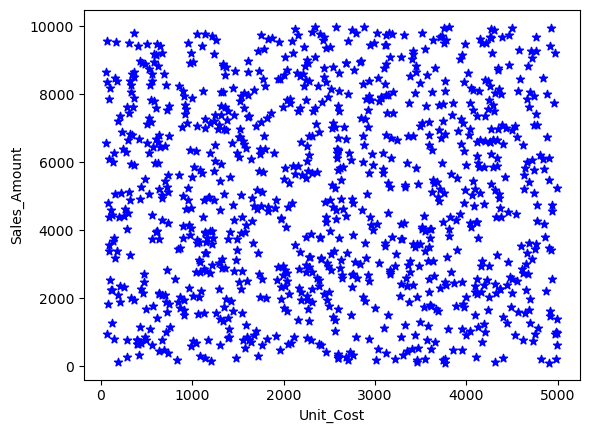

In [7]:
%matplotlib inline
#label axis
plt.xlabel('Unit_Cost')
plt.ylabel('Sales_Amount')
plt.scatter(df['Unit_Cost'], df['Sales_Amount'], color='blue', marker='*', label='real data')
plt.show()

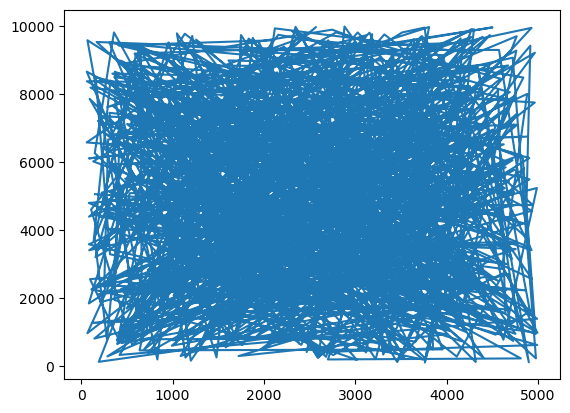

In [8]:
#best fit regression line
plt.plot(df['Unit_Cost'], df['Sales_Amount'])
plt.show()

SELECT TARGET, FEATURES AND SPLIT DATA

In [10]:
X = df[['Product_ID','Unit_Cost', 'Quantity_Sold', 'Unit_Price','Discount']]
y = df['Sales_Amount']
#Splitinto traing and testing set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2, random_state=1)

In [11]:
X.describe()

,Product_ID,Unit_Cost,Quantity_Sold,Unit_Price,Discount
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000
mean,1050.128000,2475.304550,25.355000,2728.440120,0.15239
std,29.573505,1417.872546,14.159006,1419.399839,0.08720
min,1001.000000,60.280000,1.000000,167.120000,0.00000
25%,1024.000000,1238.380000,13.000000,1509.085000,0.08000
50%,1051.000000,2467.235000,25.000000,2696.400000,0.15000
75%,1075.000000,3702.865000,38.000000,3957.970000,0.23000
max,1100.000000,4995.300000,49.000000,5442.150000,0.30000


ANOTHER METHOD OF SELECTING THE TARGET
y= df.Sales_Amount
y

In [12]:
y.describe()

count    1000.000000
mean     5019.265230
std      2846.790126
min       100.120000
25%      2550.297500
50%      5019.300000
75%      7507.445000
max      9989.040000
Name: Sales_Amount, dtype: float64

Fit and Train the model

In [13]:
#Initialise tthe model
model = LinearRegression()
#train the model, fitting
model.fit(X_train, y_train)
#training completed

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [14]:
print("Making predictions for the following 5 products:")
print(X.head())
print("The predictions are")
print("\n")
print(model.predict(X.head()))

Making predictions for the following 5 products:
   Product_ID  Unit_Cost  Quantity_Sold  Unit_Price  Discount
0        1052     152.75             18      267.22      0.09
1        1093    3816.39             17     4209.44      0.11
2        1015     261.56             30      371.40      0.20
3        1072    4330.03             39     4467.75      0.02
4        1061     637.37             13      692.71      0.08
The predictions are


[4914.21686449 5197.32413197 4861.91898872 4764.13081604 4928.0918997 ]


MAKE PREDICTIONS USING THE TEST DATA

In [15]:
#make predictions using the test data
predictions = model.predict(X_test)
print(f"Predicted price: {predictions[0]}") #prediction for th first value of test data
print("\n")
print(f"Actual price: {y_test.values[0]}")
print(f"MAE = ", mean_absolute_error(y_test, predictions))

Predicted price: 5119.0599331140365


Actual price: 4481.2
MAE =  2427.62923232074


CALCULATE THE MEAN-ABSOLUTE ERROR

In [ ]:
predicted_sales = model.predict(X)
mean_absolute_error(y, predicted_sales)